# **Online Retail lakehouse project**

# 1. Background and objectives


## Prerequisite

### System setup

In [ ]:
%%capture
!pip install pyspark==3.5.3
!pip install -q delta-spark==3.2.1
!pip install -q python-dotenv
!pip install pyngrok

In [ ]:
!pip list|grep spark

dataproc-spark-connect                   1.0.1
delta-spark                              3.2.1
pyspark                                  3.5.3


In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv
from pyspark import SparkConf
from pyspark.sql import SparkSession


def _find_dotenv():
    """Cherche un fichier .env en remontant depuis le répertoire de travail courant."""
    cwd = Path.cwd().resolve()
    for directory in [cwd, *cwd.parents]:
        candidate = directory / ".env"
        if candidate.is_file():
            return candidate
    return None


_env_file = _find_dotenv()
if _env_file:
    load_dotenv(_env_file)

ENV = os.getenv("ENV", "dev")
_project_root = Path.cwd().resolve()
_default_raw = _project_root / "Data_OR" / "Online_Retail.csv"
RAW_PATH = os.getenv("RAW_PATH") or str(_default_raw)
CURATED_PATH = (os.getenv("CURATED_PATH") or "").strip().rstrip("/")

local = "local[*]"
appName = "Capstone project with Delta Lake  "
localConfig = SparkConf().setAppName(appName).setMaster(local).\
  set("spark.executor.memory", "8G").\
  set("spark.driver.memory","8G").\
  set("spark.sql.catalogImplementation","in-memory").\
  set("spark.sql.extensions","io.delta.sql.DeltaSparkSessionExtension").\
  set("spark.sql.catalog.spark_catalog","org.apache.spark.sql.delta.catalog.DeltaCatalog").\
  set("spark.jars.packages","io.delta:delta-spark_2.12:3.1.0").\
  set("spark.databricks.delta.schema.autoMerge.enabled","true")

if CURATED_PATH:
    localConfig = localConfig.set("spark.sql.warehouse.dir", CURATED_PATH)

spark = SparkSession.builder.config(conf = localConfig).getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("ERROR")

print(f"ENV={ENV}")
print(f"RAW_PATH={RAW_PATH}")
print(f"CURATED_PATH={CURATED_PATH or '(défaut Spark — ex. ./spark-warehouse en local)'}")

In [ ]:
spark

### Data import

In [ ]:
from pathlib import Path

print(f"ENV={ENV} | RAW_PATH={RAW_PATH}")
_local = RAW_PATH.replace("file://", "", 1)
p = Path(_local)
if p.is_file():
    print("Fichier brut OK:", p.resolve())
elif p.parent.is_dir():
    print("Contenu du dossier:", [x.name for x in sorted(p.parent.iterdir())])
else:
    print("(Contrôle local uniquement ; pour s3a:// vérifiez les credentials Hadoop/AWS.)")

Online_Retail.csv


In [ ]:
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(RAW_PATH)


In [ ]:
df.show(10, truncate=False)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/2010 08:26:00,7.65,17850,United Kingdom
536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/2010 08:26:00,4.25,17850,United Kingdom
536366,22633,HAND WARMER UNION JACK,6,01/12/2010 08:28:00,1.85,17850,United Kingdom
536366,22632,HAND WARMER RED POLKA DOT,6,01/12/2010 08:28:00,1.85,17850,United Kingdom


In [ ]:
_path_sql = RAW_PATH.replace('"', '\\"')
query = f"""
CREATE TABLE IF NOT EXISTS DF_OR
USING csv
OPTIONS (
  header "true",
  path "{_path_sql}",
  inferSchema "true"
)
"""
spark.sql(query)

DataFrame[]

# 2. Data ingestion and understanding

In this part, we will get some knowledge about the data by reading its schema and extracting  some basic statistical information about the values of columns that you will find interesting.

In [ ]:
query = """
DESCRIBE DF_OR
"""
spark.sql(query).show()

+-----------+---------+-------+
|   col_name|data_type|comment|
+-----------+---------+-------+
|  InvoiceNo|   string|   NULL|
|  StockCode|   string|   NULL|
|Description|   string|   NULL|
|   Quantity|   string|   NULL|
|InvoiceDate|   string|   NULL|
|  UnitPrice|   string|   NULL|
| CustomerID|   string|   NULL|
|    Country|   string|   NULL|
+-----------+---------+-------+



In [ ]:
query = """
SELECT * FROM DF_OR TABLESAMPLE (5 ROWS);
"""
spark.sql(query).show()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|01/12/2010 08:26:00|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|01/12/2010 08:26:00|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|01/12/2010 08:26:00|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|01/12/2010 08:26:00|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|01/12/2010 08:26:00|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+



In [ ]:
query = """
select count(*) from DF_OR
"""
spark.sql(query).show()

+--------+
|count(1)|
+--------+
|  541909|
+--------+



In [ ]:
query = """
SELECT *
FROM DF_OR
TABLESAMPLE (5000 ROWS)
"""
small = spark.sql(query)

In [ ]:
small.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|01/12/2010 08:26:00|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|01/12/2010 08:26:00|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|01/12/2010 08:26:00|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|01/12/2010 08:26:00|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|01/12/2010 08:26:00|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows



In [ ]:
%%capture
! pip install ydata_profiling

In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
OR_report = ProfileReport(small,
                title='Customers Purchase',
                infer_dtypes=False,
                interactions=None,
                missing_diagrams=None,
                correlations=None)

In [ ]:
OR_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 3. Cleaning the data and selecting relevant columns

In [ ]:
from pyspark.sql.functions import col, to_timestamp

In [ ]:
phase0 = (
    df
    .withColumn("Quantity", col("Quantity").cast("int"))
    .withColumn("UnitPrice", col("UnitPrice").cast("double"))
    .withColumn("InvoiceDate",to_timestamp(col("InvoiceDate"), "dd/MM/yyyy HH:mm:ss")
    )
)

In [ ]:
# .withColumn("InvoiceNo", col("InvoiceNo").cast("long"))

In [ ]:
phase1 = (
    phase0
    .filter(col("CustomerID").isNotNull())
    .filter(col("UnitPrice").isNotNull())
    .filter(col("Quantity").isNotNull())
    .filter(col("InvoiceNo").isNotNull())
)

In [ ]:
phase1 = phase1.withColumn(
    "OrderAmount",
    col("Quantity") * col("UnitPrice")
)

In [ ]:
phase1.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("phase1")

##### Dropping

In [ ]:
# spark.sql("DROP TABLE phase1")

spark.sql("DROP TABLE IF EXISTS phase1")
spark.sql("DROP TABLE IF EXISTS phase2")
spark.sql("DROP TABLE IF EXISTS phase3")
spark.sql("DROP TABLE IF EXISTS phase4")
spark.sql("DROP TABLE IF EXISTS sales_clus_country_Shopsize")
spark.sql("DROP TABLE IF EXISTS sales_per_country_continent")

In [ ]:
# query = """ SHOW Tables """
# spark.sql(query).show()

#### Removal of cancelled orders

In [ ]:
query = """ SELECT COUNT(*)
FROM phase1
WHERE lower(InvoiceNo) LIKE 'c%';
"""

In [ ]:
spark.sql(query).show()

+--------+
|count(1)|
+--------+
|    8839|
+--------+



In [ ]:
query = """
DELETE FROM phase1 WHERE lower(InvoiceNo) LIKE 'c%';
"""

spark.sql(query).show()

+-----------------+
|num_affected_rows|
+-----------------+
|             8839|
+-----------------+



In [ ]:
query = """ SELECT COUNT(*)
FROM phase1
WHERE lower(InvoiceNo) LIKE 'c%';
"""
spark.sql(query).show()

+--------+
|count(1)|
+--------+
|       0|
+--------+



In [ ]:
phase1.select("Quantity", "UnitPrice").describe().show()

+-------+------------------+-----------------+
|summary|          Quantity|        UnitPrice|
+-------+------------------+-----------------+
|  count|            403182|           403182|
|   mean|12.036861764662113|3.475407369376114|
| stddev|172.75679516716042|69.62736450163644|
|    min|            -74215|              0.0|
|    max|             74215|          38970.0|
+-------+------------------+-----------------+



#### Removal of outliers

In [ ]:
# phase1.select("CustomerID", "StockCode", "InvoiceNo", "Quantity", "UnitPrice").orderBy("Quantity", ascending= False).show(5)

In [ ]:
query = """ DELETE FROM phase1
WHERE InvoiceNo = '541431';
"""
spark.sql(query).show()

+-----------------+
|num_affected_rows|
+-----------------+
|                1|
+-----------------+



#### Deletion of observations that are not articles

In [ ]:
# phase1.select("CustomerID", "StockCode", "Description", "InvoiceNo", "Quantity", "UnitPrice").orderBy("UnitPrice", ascending= False).show(20)

In [ ]:
query = """ DELETE FROM phase1
WHERE length(StockCode) <> 5;
"""
spark.sql(query).show()

+-----------------+
|num_affected_rows|
+-----------------+
|            33707|
+-----------------+



##### Refreshing

In [ ]:
spark.catalog.clearCache()
phase1 = spark.table("phase1")

##### New summary

In [ ]:
phase1.select("Quantity", "UnitPrice").describe().show()

+-------+-----------------+------------------+
|summary|         Quantity|         UnitPrice|
+-------+-----------------+------------------+
|  count|           360635|            360635|
|   mean|12.67808726274488|2.8916543042152556|
| stddev|48.09559782709262| 4.370442553125178|
|    min|                1|               0.0|
|    max|            12540|             649.5|
+-------+-----------------+------------------+



## Descriptive statistics

#### Shape

In [ ]:
print("Nombre de lignes :", phase1.count())
print("Nombre de colonnes :", len(phase1.columns))

Nombre de lignes : 360635
Nombre de colonnes : 9


**After the end of the bronze phase we got now 360k observations**

#### Schema

In [ ]:
phase1.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- OrderAmount: double (nullable = true)



#### Transactions by country

In [ ]:
phase1.groupBy("Country").count().orderBy("count", ascending=False).show()

+---------------+------+
|        Country| count|
+---------------+------+
| United Kingdom|321276|
|        Germany|  8077|
|         France|  7633|
|           EIRE|  6531|
|    Netherlands|  2210|
|          Spain|  2204|
|        Belgium|  1790|
|    Switzerland|  1661|
|       Portugal|  1343|
|      Australia|  1114|
|         Norway|   973|
|Channel Islands|   701|
|          Italy|   691|
|         Cyprus|   569|
|        Finland|   527|
|         Sweden|   409|
|        Austria|   357|
|        Denmark|   337|
|         Poland|   299|
|          Japan|   297|
+---------------+------+
only showing top 20 rows



Customer statistics

In [ ]:
phase1.select("CustomerID").distinct().count()

4313

Cardinality of categorical variables

In [ ]:
phase1.select("StockCode").distinct().count()

2765

In [ ]:
phase1.select("Description").distinct().count()

2946

In [ ]:
phase1.select("Country").distinct().count()

37

# 4. Enrichments and transformations

In this part we will make some changes to the database and discretise certain variables for future analyses.

In [ ]:
from pyspark.sql.functions import when

New column OrderAmount

In [ ]:
phase2 = phase1.withColumn(
    "OrderAmount",
    col("Quantity") * col("UnitPrice")
)

#### Adding constraint on price and quantity

In [ ]:
phase2 = (
    phase2
    .select(
        "CustomerID",
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "Country",
        "OrderAmount"
    )
    .where(col("UnitPrice") > 0)
    .where(col("Quantity") > 0)
)


In [ ]:
phase2.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("phase2")

In [ ]:
query = """
select count(*) from phase2
"""
spark.sql(query).show()

+--------+
|count(1)|
+--------+
|  360603|
+--------+



Renammed of StockCode

In [ ]:
phase2 = phase2.withColumnRenamed("StockCode", "ItemCode")

In [ ]:
from pyspark.sql.functions import min, max, avg, expr, round, rand, trim, upper, lower, sum, count, when

In [ ]:
from pyspark.sql.window import Window

### Continuation of descriptive statistics

In [ ]:
phase2.select(
    min("OrderAmount").alias("min"),
    max("OrderAmount").alias("max"),
    round(avg("OrderAmount"),1).alias("avg"),
    round(expr("percentile_approx(OrderAmount, 0.25)"),1).alias("Q1"),
    round(expr("percentile_approx(OrderAmount, 0.5)"),1).alias("median"),
    round(expr("percentile_approx(OrderAmount, 0.75)"),1).alias("Q3")
).show()

+----+-------+----+---+------+----+
| min|    max| avg| Q1|median|  Q3|
+----+-------+----+---+------+----+
|0.06|38970.0|21.4|4.9|  12.5|19.8|
+----+-------+----+---+------+----+



Top 10 gros clients

In [ ]:
phase2.groupBy("CustomerID") \
  .agg(round(sum("OrderAmount"),2).alias("TotalDepense")) \
  .orderBy("TotalDepense", ascending=False) \
  .show(10)

+----------+------------+
|CustomerID|TotalDepense|
+----------+------------+
|     14646|   263689.48|
|     18102|   253922.76|
|     17450|   180847.03|
|     14911|   125199.38|
|     12415|   119534.15|
|     14156|   112252.91|
|     17511|    80817.51|
|     16029|    65153.49|
|     16684|    59521.72|
|     17949|    57767.68|
+----------+------------+
only showing top 10 rows



Revenue by country

In [ ]:
w_total = Window.partitionBy()

In [ ]:
ca_by_country = phase2.groupBy("Country") \
    .agg(round(sum("OrderAmount"), 2).alias("ChiffreAffaires")) \
    .withColumn(
        "Part_CA_pct",
        round(col("ChiffreAffaires") / sum("ChiffreAffaires").over(w_total) * 100, 2)
    ) \
    .orderBy(col("ChiffreAffaires").desc())

ca_by_country.show()

+---------------+---------------+-----------+
|        Country|ChiffreAffaires|Part_CA_pct|
+---------------+---------------+-----------+
| United Kingdom|      6341765.5|      82.08|
|    Netherlands|      267912.74|       3.47|
|           EIRE|      241392.32|       3.12|
|        Germany|      189372.59|       2.45|
|         France|      173291.87|       2.24|
|      Australia|      132323.54|       1.71|
|    Switzerland|       47943.01|       0.62|
|          Spain|       42967.29|       0.56|
|          Japan|       35250.61|       0.46|
|         Sweden|       35009.25|       0.45|
|        Belgium|       34682.45|       0.45|
|         Norway|        28607.8|       0.37|
|       Portugal|       25127.55|       0.33|
|Channel Islands|       18146.69|       0.23|
|        Denmark|       17044.87|       0.22|
|          Italy|       14628.02|       0.19|
|        Finland|       11940.47|       0.15|
|         Cyprus|       11711.18|       0.15|
|      Singapore|        8651.87| 

#### Best-selling products in QTY and Revenue

In [ ]:
phase2.groupBy("ItemCode") \
  .agg(sum("Quantity").alias("TotalQuantite")) \
  .orderBy("TotalQuantite", ascending=False) \
  .show(10, truncate=False)

+--------+-------------+
|ItemCode|TotalQuantite|
+--------+-------------+
|84077   |54415        |
|22197   |49183        |
|84879   |35362        |
|21212   |33693        |
|23084   |27202        |
|22492   |26076        |
|22616   |25345        |
|21977   |24264        |
|17003   |22963        |
|22178   |22433        |
+--------+-------------+
only showing top 10 rows



In [ ]:
phase2.groupBy("ItemCode") \
  .agg(round(sum("OrderAmount"), 2).alias("CA_Produit")) \
  .withColumn(
        "Part_CA_pct",
        round(col("CA_Produit") / sum("CA_Produit").over(w_total) * 100, 2)
    ) \
  .orderBy("CA_Produit", ascending=False) \
  .show(10, truncate=False)

+--------+----------+-----------+
|ItemCode|CA_Produit|Part_CA_pct|
+--------+----------+-----------+
|22423   |142592.95 |1.85       |
|47566   |68844.33  |0.89       |
|84879   |56580.34  |0.73       |
|23084   |51346.2   |0.66       |
|22502   |47366.2   |0.61       |
|79321   |46286.51  |0.6        |
|22086   |42660.83  |0.55       |
|21137   |39064.55  |0.51       |
|23203   |37684.38  |0.49       |
|22386   |37289.59  |0.48       |
+--------+----------+-----------+
only showing top 10 rows



In [ ]:
df_orders = (
    phase2.groupBy("InvoiceNo")
      .agg(count("*").alias("NbItem"), sum("Quantity").alias("QuantiteTotale"))
      .orderBy("Nbitem", ascending=False)
)

In [ ]:
df_orders.show(10)

+---------+------+--------------+
|InvoiceNo|NbItem|QuantiteTotale|
+---------+------+--------------+
|   576339|   481|          1854|
|   579196|   481|          1814|
|   580727|   468|          1839|
|   578270|   397|          1634|
|   573576|   380|          1044|
|   567656|   371|          1023|
|   567183|   371|          2554|
|   575607|   329|           874|
|   571441|   319|           871|
|   570488|   310|           686|
+---------+------+--------------+
only showing top 10 rows



In [ ]:
from pyspark.sql.functions import min, max, avg, expr, round

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import sum

In [ ]:
top100 = phase2.orderBy(col("OrderAmount").desc()).limit(100)

In [ ]:
w = Window.orderBy(col("OrderAmount").desc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)
top100 = top100.withColumn(
    "cum_amount",
    sum("OrderAmount").over(w)
)

In [ ]:
# Calcul du total CA des 100 commandes
total_CA = top100.agg(sum("OrderAmount").alias("total_CA")).collect()[0]["total_CA"]

# Ajout de la colonne % cumulé
top100 = top100.withColumn(
    "cum_pct",
    round(col("cum_amount") / total_CA * 100, 2)  # pourcentage arrondi à 2 décimales
)

In [ ]:
top100.select("InvoiceNo", "CustomerID", "OrderAmount", "cum_amount", "cum_pct").show(32)

+---------+----------+------------------+------------------+-------+
|InvoiceNo|CustomerID|       OrderAmount|        cum_amount|cum_pct|
+---------+----------+------------------+------------------+-------+
|   556444|     15098|           38970.0|           38970.0|  12.35|
|   567423|     17450| 7144.719999999999|          46114.72|  14.62|
|   540815|     15749| 6539.400000000001|          52654.12|  16.69|
|   550461|     15749| 6539.400000000001|59193.520000000004|  18.76|
|   573003|     14646|            4992.0|64185.520000000004|  20.35|
|   540818|     15749|            4522.5|          68708.02|  21.78|
|   558526|     17949|            4401.0|          73109.02|  23.18|
|   550461|     15749|            4254.5|          77363.52|  24.52|
|   562439|     12931|            4176.0|          81539.52|  25.85|
|   540689|     17450|           4121.64|          85661.16|  27.15|
|   581115|     15195|            3861.0|          89522.16|  28.38|
|   537659|     18102|            

## Visualisations

In [ ]:
import matplotlib.pyplot as plt

#### Revenue by order

<Axes: >

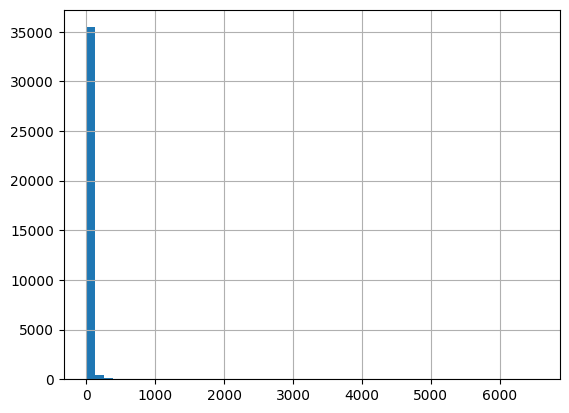

In [ ]:
sample = phase2.select("OrderAmount").sample(fraction=0.1).toPandas()

sample["OrderAmount"].hist(bins=50)

#### Revenue by country

In [ ]:
df_country = (
    phase2.groupBy("Country")
      .agg(sum("OrderAmount").alias("CA"))
      .orderBy("CA", ascending=False)
)

pdf_country = df_country.toPandas()

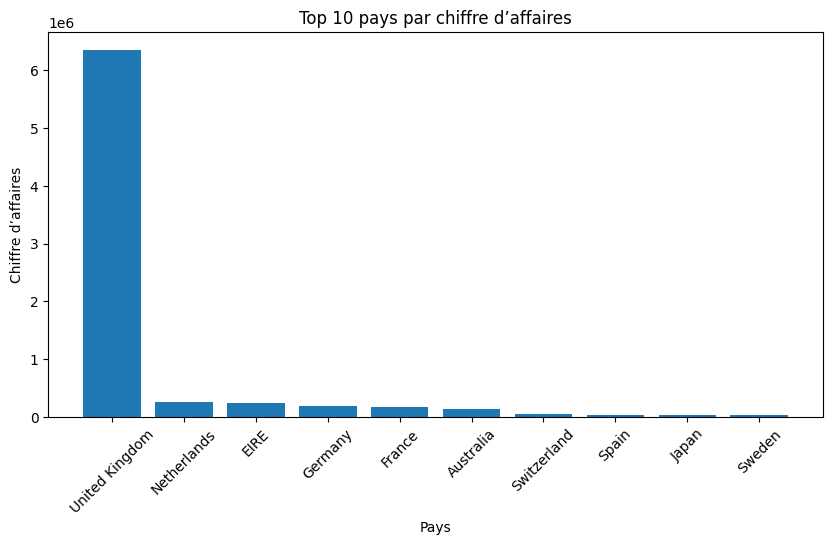

In [ ]:
top10 = pdf_country.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Country"], top10["CA"])
plt.xticks(rotation=45)
plt.title("Top 10 pays par chiffre d’affaires")
plt.xlabel("Pays")
plt.ylabel("Chiffre d’affaires")
plt.show()

#### Revenue growth over time

In [ ]:
from pyspark.sql.functions import year, month

In [ ]:
df_time = (
    phase2.withColumn("Year", year("InvoiceDate"))
      .withColumn("Month", month("InvoiceDate"))
      .groupBy("Year", "Month")
      .agg(sum("OrderAmount").alias("CA"))
      .orderBy("Year", "Month")
)

pdf_time = df_time.toPandas()


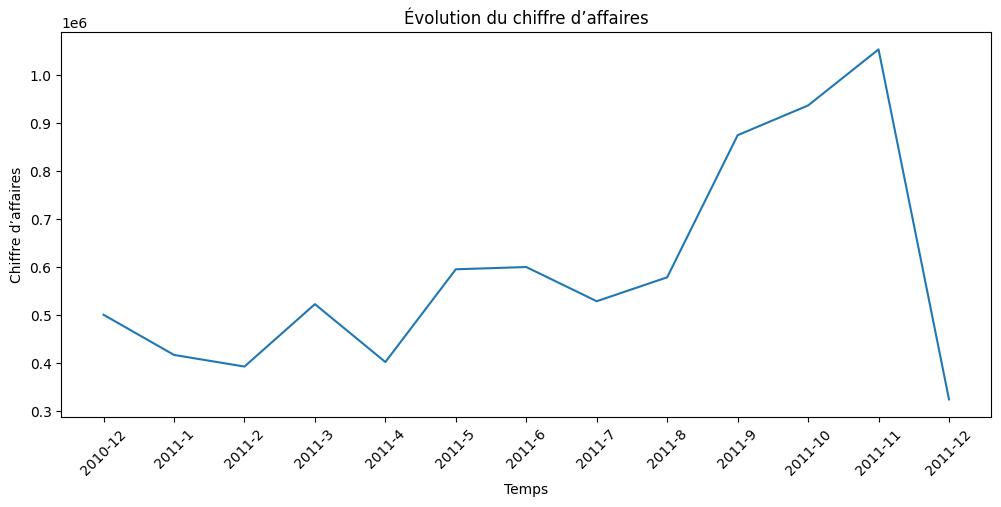

In [ ]:
pdf_time["Date"] = pdf_time["Year"].astype(str) + "-" + pdf_time["Month"].astype(str)

plt.figure(figsize=(12,5))
plt.plot(pdf_time["Date"], pdf_time["CA"])
plt.xticks(rotation=45)
plt.title("Évolution du chiffre d’affaires")
plt.xlabel("Temps")
plt.ylabel("Chiffre d’affaires")
plt.show()

## Variable discretisation and creation

### Creation of order segments

In [ ]:
phase2 = phase2.withColumn(
    "Purchase_segment",
    when(col("OrderAmount") < 5, "Low")
    .when(col("OrderAmount") < 20, "Medium")
    .otherwise("High")
)

In [ ]:
phase2 = phase2.withColumn(
    "High_spender",
    (col("OrderAmount") > 100).cast("boolean")
)

## Création des variables continent et shopsize

##### Quantile

In [ ]:
# phase1.selectExpr("percentile_approx(Quantity, 0.25) as Q1",
#    "percentile_approx(Quantity, 0.75) as Q3").show()

#### Adding and recoding

In [ ]:
phase2 = phase2.withColumn(
    "Shopsize",
    when(col("Quantity") < 3, "Small")
    .when(col("Quantity") < 12, "Medium")
    .when(col("Quantity") < 50, "Big")
    .otherwise("Very_Big")
)

In [ ]:
phase2 = phase2.withColumn(
    "Continent",
    when(col("Country").contains("Australia"), "Europa")
    .when(col("Country").contains("EIRE"), "Europa")
    .when(col("Country").contains("Iceland"), "Europa")
    .when(col("Country").contains("United Arab Emirates"), "Eurasia")
    .when(col("Country").contains("Israel"), "Eurasia")
    .when(col("Country").contains("Channel Islands"), "Europa")
    .when(col("Country").contains("Cyprus"), "Europa")
    .when(col("Country").contains("Sweden"), "Europa")
    .when(col("Country").contains("RSA"), "Europa")
    .when(col("Country").contains("Denmark"), "Europa")
    .when(col("Country").contains("Bahrain"), "Asia")
    .when(col("Country").contains("United Kingdom"), "Europa")
    .when(col("Country").contains("Switzerland"), "Europa")
    .when(col("Country").contains("Lithuania"), "Europa")
    .when(col("Country").contains("Czech Republic"), "Europa")
    .when(col("Country").contains("Norway"), "Europa")
    .when(col("Country").contains("Austria"), "Europa")
    .when(col("Country").contains("European Community"), "Europa")
    .when(col("Country").contains("Netherlands"), "Europa")
    .when(col("Country").contains("Spain"), "Europa")
    .when(col("Country").contains("Italy"), "Europa")
    .when(col("Country").contains("Japan"), "Asia")
    .when(col("Country").contains("Finland"), "Europa")
    .when(col("Country").contains("Saudi Arabia"), "Eurasia")
    .when(col("Country").contains("Brazil"), "Southamerica")
    .when(col("Country").contains("France"), "Europa")
    .when(col("Country").contains("Germany"), "Europa")
    .when(col("Country").contains("Poland"), "Europa")
    .when(col("Country").contains("USA"), "Northamerica")
    .when(col("Country").contains("Malta"), "Europa")
    .when(col("Country").contains("Portugal"), "Europa")
    .when(col("Country").contains("Greece"), "Europa")
    .when(col("Country").contains("Singapore"), "Asia")
    .when(col("Country").contains("Lebanon"), "Eurasia")
    .when(col("Country").contains("Canada"), "Northamerica")
    .otherwise("Other")
)

### Création de la variables Category

In [ ]:
from pyspark.sql.functions import regexp_replace, split, lower, explode

We normalized categorical values by trimming leading and trailing whitespaces to avoid duplicated categories caused by formatting inconsistencies.

##### Synthax

In [ ]:
phase2 = phase2.withColumn(
    "Description",
    upper(trim(col("Description")))
)

In [ ]:
# phase2 = phase2.withColumn("Description",regexp_replace(col("Description"), "[^a-z ]", ""))

In [ ]:
df_clean = phase2.withColumn(
    "tokens",
    split(
        lower(col("Description")),
        " "
    )
)

#### Divide of dataset

In [ ]:
df_clean_5000 = df_clean.orderBy(rand()).limit(5000)

df_clean_rest = df_clean.join(df_clean_5000, on=phase2.columns, how="left_anti")

In [ ]:
df_clean_5000.select(upper(trim(col("Description"))).alias("Description_clean")) \
  .distinct() \
  .show(10)

+--------------------+
|   Description_clean|
+--------------------+
|SET/10 RED POLKAD...|
|JAM MAKING SET WI...|
|PEACE WOODEN BLOC...|
|WOODEN PICTURE FR...|
|EUCALYPTUS & PINE...|
|CHERRY CROCHET FO...|
|    PARTY METAL SIGN|
|KEY RING BASEBALL...|
|SWEETHEART BIRD H...|
|SET 6 PAPER TABLE...|
+--------------------+
only showing top 10 rows



In [ ]:
stopwords = [
    "the","and","a","to","of","in","for","on","with","is",
    "this","that","it","at","by","an", " "
]

### Split by bigrams

#### Tokenizer method

In [ ]:
from pyspark.ml.feature import Tokenizer

In [ ]:
tokenizer = Tokenizer(
    inputCol="Description",
    outputCol="words"
)

df_words = tokenizer.transform(df_clean_5000)


In [ ]:
from pyspark.ml.feature import StopWordsRemover

In [ ]:
custom_stopwords = StopWordsRemover.loadDefaultStopWords("english") + [
    " ", "of ", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"
]

remover = StopWordsRemover(
    inputCol="words",
    outputCol="words_clean",
    stopWords=custom_stopwords
)

df_clean = remover.transform(df_words)


In [ ]:
from pyspark.ml.feature import NGram

In [ ]:
bigrammer = NGram(
    n=2,
    inputCol="words_clean",
    outputCol="bigrams"
)

df_bigrams = bigrammer.transform(df_clean)


In [ ]:
top_bigrams = df_bigrams \
    .select(explode(col("bigrams")).alias("bigram")) \
    .groupBy("bigram") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(100)

In [ ]:
top_bigrams.show(30)

+-----------------+-----+
|           bigram|count|
+-----------------+-----+
|    red retrospot|  177|
|        lunch bag|  153|
|        jumbo bag|  133|
|       metal sign|  125|
|       cake cases|   99|
|        hot water|   84|
|     water bottle|   84|
|       dolly girl|   78|
|vintage christmas|   75|
|   t-light holder|   66|
|      bag vintage|   64|
|      drawer knob|   58|
|       union jack|   54|
|    pantry design|   54|
|    charlotte bag|   53|
|    pink polkadot|   52|
|        lunch box|   49|
|   50's christmas|   47|
|         bag pink|   46|
|      hand warmer|   46|
|     plasters tin|   46|
|      alarm clock|   45|
|   clock bakelike|   45|
|     white finish|   38|
|     vintage leaf|   38|
|      paper chain|   36|
|        chain kit|   36|
|  spaceboy design|   36|
|       home sweet|   36|
|       sweet home|   36|
+-----------------+-----+
only showing top 30 rows



In [ ]:
df_clean_5000 = df_clean_5000.withColumn(
    "desc_clean",
    lower(col("Description"))
)

In [ ]:
df_categorized = df_clean_5000.withColumn(
    "product_category",
    when(col("desc_clean").contains("clock"), "Clocks")
    .when(col("desc_clean").contains("bag"), "Bags")
    .when(col("desc_clean").contains("heart"), "Hearts object")
    .when(col("desc_clean").contains("retrospot"), "Retrospots")
    .when(col("desc_clean").contains("cake"), "Cakes")
    .otherwise("Others")
)

In [ ]:
df_categorized.select("product_category").distinct().show()

+----------------+
|product_category|
+----------------+
|          Others|
|   Hearts object|
|            Bags|
|          Clocks|
|           Cakes|
|      Retrospots|
+----------------+



#### product_category

In [ ]:
df_categorized.groupBy("product_category").count().orderBy("count", ascending=False).show()

+----------------+-----+
|product_category|count|
+----------------+-----+
|          Others| 3553|
|            Bags|  484|
|   Hearts object|  426|
|      Retrospots|  269|
|           Cakes|  197|
|          Clocks|   71|
+----------------+-----+



#### Storage

In [ ]:
phase3 = df_categorized

In [ ]:
phase3.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("phase3")

#### Silver schema

In [ ]:
phase3.printSchema()

root
 |-- CustomerID: string (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- ItemCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- Country: string (nullable = true)
 |-- OrderAmount: double (nullable = true)
 |-- Purchase_segment: string (nullable = false)
 |-- High_spender: boolean (nullable = true)
 |-- Shopsize: string (nullable = false)
 |-- Continent: string (nullable = false)
 |-- tokens: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- desc_clean: string (nullable = true)
 |-- product_category: string (nullable = false)



### Contraintes

In [ ]:
query = """ALTER TABLE phase3
ADD CONSTRAINT purchase_positive
CHECK (OrderAmount > 0);
"""
spark.sql(query).show()

++
||
++
++



In [ ]:
query = """ALTER TABLE phase3
ADD CONSTRAINT invoice_not_cancelled
CHECK (lower(InvoiceNo) NOT LIKE 'c%');
"""
spark.sql(query).show()

++
||
++
++



This constraint prevents cancelled transactions (identified by invoice numbers starting with 'C') from being inserted into the curated dataset, ensuring that only effective purchases contribute to revenue analyses.

In [ ]:
query = """ALTER TABLE phase3
ADD CONSTRAINT itemcode_length_check
CHECK (length(ItemCode) = 5);
"""
spark.sql(query).show()

++
||
++
++



Product identifiers were constrained to a fixed length to ensure consistency across records and avoid malformed product codes that could impact joins and aggregations.

#### Refreshing and storage

In [ ]:
spark.catalog.clearCache()
phase3 = spark.table("phase3")

In [ ]:
# Récupérer toutes les colonnes sauf celle à supprimer
cols_to_keep = [c for c in phase3.columns if c != "tokens"]

phase3_new = phase3.select(*cols_to_keep)

In [ ]:
phase3_new.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("phase4")

# 5. Performance optimisation

## Partitionning and bucketing between 2 plans

### Adaptative optimization

In [ ]:
#disable adaptive optimization
spark.conf.set("spark.sql.adaptive.enabled", False)
#set number of paritions to 8
#spark.conf.set("spark.sql.shuffle.partitions", "8")

In [ ]:
spark.sparkContext.setJobDescription('selection Country=France')
query = """
select CustomerID from phase4 where Country='France'
"""
spark.sql(query).collect()[1]

Row(CustomerID='12683')

#### AQE Schema

                  ┌───────────────────────────┐
                  │   SQL Query Input          │
                  │ SELECT CustomerID          │
                  │ FROM phase4               │
                  │ WHERE Country='France'    │
                  └─────────────┬─────────────┘
                                │
                                ▼
                  ┌───────────────────────────┐
                  │ 1️⃣ Parsed Logical Plan     │
                  │ - Projection CustomerID     │
                  │ - Filter Country='France'   │
                  │ - UnresolvedRelation phase4 │
                  └─────────────┬─────────────┘
                                │
                                ▼
                  ┌───────────────────────────┐
                  │ 2️⃣ Analyzed Logical Plan   │
                  │ - Columns resolved         │
                  │   CustomerID: string       │
                  │ - Table schema known       │
                  │ - Filter and Project clear │
                  └─────────────┬─────────────┘
                                │
                                ▼
                  ┌───────────────────────────┐
                  │ 3️⃣ Optimized Logical Plan  │
                  │ - Null checks added        │
                  │   (isnotnull(Country))     │
                  │ - Filter pushdown planned  │
                  │ - Redundant ops removed    │
                  └─────────────┬─────────────┘
                                │
                                ▼
                  ┌───────────────────────────┐
                  │ 4️⃣ Physical Plan           │
                  │ - FileScan Parquet          │
                  │ - Filter Pushdown (Country) │
                  │ - ColumnarToRow conversion │
                  │ - Projection CustomerID     │
                  │ - AQE can adjust partition  │
                  └───────────────────────────┘


At the parsed stage, Spark only interprets the SQL syntax and builds a preliminary logical plan without yet resolving table metadata.

The optimized logical plan refines the operations to improve efficiency, including null checks and filter simplification, while keeping the same logical meaning.

#### By country and continent

In [ ]:
query = """
CREATE TABLE IF NOT EXISTS sales_per_country_continent
USING csv
PARTITIONED BY (Country, Continent)
AS SELECT * FROM phase4
"""
spark.sql(query)

DataFrame[]

In [ ]:
query = """
SHOW PARTITIONS sales_per_country_continent
"""
spark.sql(query).show(truncate=False)

+----------------------------------------+
|partition                               |
+----------------------------------------+
|Country=Australia/Continent=Europa      |
|Country=Austria/Continent=Europa        |
|Country=Belgium/Continent=Other         |
|Country=Canada/Continent=Northamerica   |
|Country=Channel Islands/Continent=Europa|
|Country=Cyprus/Continent=Europa         |
|Country=Denmark/Continent=Europa        |
|Country=EIRE/Continent=Europa           |
|Country=Finland/Continent=Europa        |
|Country=France/Continent=Europa         |
|Country=Germany/Continent=Europa        |
|Country=Greece/Continent=Europa         |
|Country=Iceland/Continent=Europa        |
|Country=Israel/Continent=Eurasia        |
|Country=Italy/Continent=Europa          |
|Country=Japan/Continent=Asia            |
|Country=Lebanon/Continent=Eurasia       |
|Country=Malta/Continent=Europa          |
|Country=Netherlands/Continent=Europa    |
|Country=Norway/Continent=Europa         |
+----------

In [ ]:
import time

In [704]:
from pyspark.sql.functions import sum, round, lpad

In [ ]:
query_non_part = """
SELECT
  Country,
  ROUND(SUM(OrderAmount),2) AS total_revenue
FROM phase4
GROUP BY Country
ORDER BY total_revenue DESC
"""

start = time.time()
spark.sql(query_non_part).show()
end = time.time()
non_part_time = end - start
print(f"Execution time (non-partitioned): {end - start} seconds")

+---------------+-------------+
|        Country|total_revenue|
+---------------+-------------+
| United Kingdom|     81486.29|
|           EIRE|      3364.99|
|      Australia|       3167.6|
|    Netherlands|       2276.1|
|        Germany|      2198.53|
|         France|      2150.26|
|          Spain|       742.25|
|    Switzerland|       698.03|
|          Japan|        644.4|
|Channel Islands|        642.3|
|         Sweden|       537.54|
|         Norway|       405.22|
|        Belgium|       391.15|
|        Finland|       324.72|
|         Cyprus|       279.53|
|       Portugal|       267.32|
|         Israel|       198.12|
|        Denmark|       190.86|
|         Poland|       169.13|
|          Italy|       101.25|
+---------------+-------------+
only showing top 20 rows

Execution time (non-partitioned): 2.4516093730926514 seconds


In [ ]:
query_part = """
SELECT
  Country,
  ROUND(SUM(OrderAmount),2) AS total_revenue
FROM sales_per_country_continent
GROUP BY Country
ORDER BY total_revenue DESC
"""

start = time.time()
spark.sql(query_part).show()
end = time.time()
part_time = end - start
print(f"Execution time (partitioned): {end - start} seconds")

+---------------+-------------+
|        Country|total_revenue|
+---------------+-------------+
| United Kingdom|     81486.29|
|           EIRE|      3364.99|
|      Australia|       3167.6|
|    Netherlands|       2276.1|
|        Germany|      2198.53|
|         France|      2150.26|
|          Spain|       742.25|
|    Switzerland|       698.03|
|          Japan|        644.4|
|Channel Islands|        642.3|
|         Sweden|       537.54|
|         Norway|       405.22|
|        Belgium|       391.15|
|        Finland|       324.72|
|         Cyprus|       279.53|
|       Portugal|       267.32|
|         Israel|       198.12|
|        Denmark|       190.86|
|         Poland|       169.13|
|          Italy|       101.25|
+---------------+-------------+
only showing top 20 rows

Execution time (partitioned): 0.9004688262939453 seconds


In [ ]:
(1 - (part_time/non_part_time)) * 100

1.551140546798706

**Gain of two third**

### Aggregate Pushdown plan

In [ ]:
spark.conf.set("spark.sql.parquet.aggregatePushdown", True)

In [ ]:
query = """
CREATE TABLE IF NOT EXISTS sales_clus_country_Shopsize
USING csv
CLUSTERED BY (Country, Shopsize) INTO 8 BUCKETS
AS SELECT * FROM phase4
"""
spark.sql(query)

DataFrame[]

##### test

In [ ]:
# query = """ DESCRIBE DETAIL sales_clus_country_purchase_segment; """

In [ ]:
# spark.sql(query).show(truncate = False)

#### Buckets

In [ ]:
! wc -l /content/spark-warehouse/sales_clus_country_shopsize/*csv

  1271 /content/spark-warehouse/sales_clus_country_shopsize/part-00000-a3e6b34f-969c-4ebd-a1f6-142c217f94ed_00000.c000.csv
  3391 /content/spark-warehouse/sales_clus_country_shopsize/part-00000-a3e6b34f-969c-4ebd-a1f6-142c217f94ed_00001.c000.csv
    99 /content/spark-warehouse/sales_clus_country_shopsize/part-00000-a3e6b34f-969c-4ebd-a1f6-142c217f94ed_00002.c000.csv
   239 /content/spark-warehouse/sales_clus_country_shopsize/part-00000-a3e6b34f-969c-4ebd-a1f6-142c217f94ed_00003.c000.csv
  5000 total


In [ ]:
! cut -d ',' -f 7,8 /content/spark-warehouse/sales_clus_country_shopsize/part*_00003.c000.csv|sort|uniq

0.04,United Kingdom
0.06,United Kingdom
0.18,United Kingdom
0.19,France
0.19,United Kingdom
0.21,United Kingdom
0.25,United Kingdom
0.27,United Kingdom
0.29,Sweden
0.29,United Kingdom
0.36,Australia
0.36,United Kingdom
0.39,France
0.39,United Kingdom
0.42,Australia
0.42,EIRE
0.42,France
0.42,United Kingdom
0.4,United Kingdom
0.53,United Kingdom
0.55,France
0.55,United Kingdom
0.65,France
0.65,Germany
0.65,United Kingdom
0.72,EIRE
0.72,United Kingdom
0.75,United Kingdom
0.79,Sweden
0.83,Denmark
0.83,United Kingdom
0.85,Belgium
0.85,Cyprus
0.85,France
0.85,Germany
0.85,United Kingdom
0.94,United Kingdom
1.04,United Kingdom
1.06,Australia
1.06,EIRE
1.06,United Kingdom
10.95,Germany
1.12,United Kingdom
125.0,Cyprus
1.25,Australia
1.25,France
1.25,Germany
1.25,United Kingdom
12.75,Germany
1.45,France
1.45,United Kingdom
14.95,Channel Islands
14.95,Finland
1.65,France
1.65,Germany
1.65,Sweden
1.65,United Kingdom
16.95,Channel Islands
16.95,Cyprus
16.95,Italy
1.69,United Kingdom
1.79,United K

##### Category per continent partition

In [ ]:
query = """
CREATE TABLE IF NOT EXISTS product_category_per_continent
USING csv
PARTITIONED BY (Continent, product_category)
AS SELECT * FROM phase4
"""
spark.sql(query)

DataFrame[]

In [ ]:
query = """
SHOW PARTITIONS product_category_per_continent
"""
spark.sql(query).show(truncate=False)

+-----------------------------------------------+
|partition                                      |
+-----------------------------------------------+
|Continent=Asia/product_category=Others         |
|Continent=Europa/product_category=Bags         |
|Continent=Europa/product_category=Cakes        |
|Continent=Europa/product_category=Clocks       |
|Continent=Europa/product_category=Hearts object|
|Continent=Europa/product_category=Others       |
|Continent=Europa/product_category=Retrospots   |
|Continent=Northamerica/product_category=Cakes  |
|Continent=Northamerica/product_category=Others |
|Continent=Other/product_category=Bags          |
|Continent=Other/product_category=Cakes         |
|Continent=Other/product_category=Clocks        |
|Continent=Other/product_category=Hearts object |
|Continent=Other/product_category=Others        |
|Continent=Other/product_category=Retrospots    |
|Continent=Southamerica/product_category=Others |
+-----------------------------------------------+


#### Plan aggregate result

In [697]:
spark.sparkContext.setJobDescription("count by product_category")

query = """ SELECT product_category, COUNT(*) AS count
FROM product_category_per_continent
GROUP BY product_category
ORDER BY count DESC
"""
spark.sql(query).collect()[1]

Row(product_category='Bags', count=467)

In [698]:
spark.sql(query).explain()

== Physical Plan ==
*(3) Sort [count#130913L DESC NULLS LAST], true, 0
+- Exchange rangepartitioning(count#130913L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=49499]
   +- *(2) HashAggregate(keys=[product_category#130905], functions=[count(1)])
      +- Exchange hashpartitioning(product_category#130905, 200), ENSURE_REQUIREMENTS, [plan_id=49495]
         +- *(1) HashAggregate(keys=[product_category#130905], functions=[partial_count(1)])
            +- *(1) Project [product_category#130905]
               +- FileScan csv spark_catalog.default.product_category_per_continent[Continent#130904,product_category#130905] Batched: false, DataFilters: [], Format: CSV, Location: CatalogFileIndex(1 paths)[file:/content/spark-warehouse/product_category_per_continent], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<>




1.   **Only the required column `product_category` is read from disk, minimizing I/O cost**
2.   **Spark performs partial aggregation before the shuffle, reducing network traffic.**

*So, optimization and partial aggregate*



#### Differences between plans

The main differences are the presence of partial aggregation, shuffle operations and global sorting, reflecting the increased complexity of the query.

*The optimizer adapts the execution strategy to the query complexity*

#### Golden schema

In [ ]:
phase4 = phase3_new

In [ ]:
phase4.printSchema()

root
 |-- CustomerID: string (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- ItemCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- Country: string (nullable = true)
 |-- OrderAmount: double (nullable = true)
 |-- Purchase_segment: string (nullable = true)
 |-- High_spender: boolean (nullable = true)
 |-- Shopsize: string (nullable = true)
 |-- Continent: string (nullable = true)
 |-- desc_clean: string (nullable = true)
 |-- product_category: string (nullable = true)



# 6. Analysing the data and ensuring query evaluation effeciency

Dépense moyenne par segment

In [ ]:
mean_spend_by_segment = """SELECT Purchase_segment, AVG(OrderAmount)
FROM phase3
GROUP BY Purchase_segment;
"""

In [ ]:
spark.sql(mean_spend_by_segment).show()

+----------------+------------------+
|Purchase_segment|  avg(OrderAmount)|
+----------------+------------------+
|            High|61.258190386427955|
|             Low|2.6021412964311623|
|          Medium|12.464403741231559|
+----------------+------------------+



Top catégories chez les gros acheteurs

In [ ]:
top_category_for_big_customer = """SELECT product_category, COUNT(*) AS Number_of_Purchase
FROM phase3
WHERE High_spender = true
GROUP BY product_category
ORDER BY Number_of_Purchase DESC;
"""

In [ ]:
spark.sql(top_category_for_big_customer).show()

+----------------+------------------+
|product_category|Number_of_Purchase|
+----------------+------------------+
|          Others|                83|
|            Bags|                18|
|      Retrospots|                 8|
|   Hearts object|                 7|
|           Cakes|                 6|
|          Clocks|                 2|
+----------------+------------------+



#### Merging of the rest on database

In [707]:
df_rest_phase4 = (
    df_clean_rest
    .withColumn("OrderAmount", col("Quantity") * col("UnitPrice"))
    .withColumn("ItemCode", lpad(col("ItemCode"), 5, "0"))
    .filter(col("OrderAmount") > 0)
    .filter(~lower(col("InvoiceNo")).startswith("c"))
)

In [708]:
cols_to_keep_phase4 = [c for c in df_rest_phase4.columns if c != "tokens"]

df_rest_phase4_new = df_rest_phase4.select(*cols_to_keep_phase4)

In [711]:
df_rest_phase4_new.write \
  .format("delta") \
  .mode("overwrite") \
  .saveAsTable("df_rest_phase5")

In [717]:
query = """ MERGE INTO phase4 t
USING df_rest_phase5 s
ON t.InvoiceNo = s.InvoiceNo
AND t.ItemCode = s.ItemCode
AND t.CustomerID = s.CustomerID

WHEN NOT MATCHED THEN
  INSERT *
  """
spark.sql(query).show()

+-----------------+----------------+----------------+-----------------+
|num_affected_rows|num_updated_rows|num_deleted_rows|num_inserted_rows|
+-----------------+----------------+----------------+-----------------+
|           355281|               0|               0|           355281|
+-----------------+----------------+----------------+-----------------+



In [718]:
query = """ SELECT COUNT(*) FROM phase4; """

spark.sql(query).show()

+--------+
|count(1)|
+--------+
|  360281|
+--------+



## Compare history Versions

In [719]:
query = """
DESCRIBE HISTORY phase4;
"""
spark.sql(query).show()

+-------+--------------------+------+--------+--------------------+--------------------+----+--------+---------+-----------+--------------+-------------+--------------------+------------+--------------------+
|version|           timestamp|userId|userName|           operation| operationParameters| job|notebook|clusterId|readVersion|isolationLevel|isBlindAppend|    operationMetrics|userMetadata|          engineInfo|
+-------+--------------------+------+--------+--------------------+--------------------+----+--------+---------+-----------+--------------+-------------+--------------------+------------+--------------------+
|      1|2026-01-16 15:07:...|  NULL|    NULL|               MERGE|{predicate -> ["(...|NULL|    NULL|     NULL|          0|  Serializable|        false|{numTargetRowsCop...|        NULL|Apache-Spark/3.5....|
|      0|2026-01-16 12:27:...|  NULL|    NULL|CREATE OR REPLACE...|{isManaged -> tru...|NULL|    NULL|     NULL|       NULL|  Serializable|        false|{numFiles -

In [721]:
query = """ WITH revenues AS (
  SELECT 'v0' AS version, Country, ROUND(SUM(OrderAmount),2) AS total_revenue
  FROM phase1 VERSION AS OF 0
  GROUP BY Country

  UNION ALL

  SELECT 'v1' AS version, Country, ROUND(SUM(OrderAmount),2) AS total_revenue
  FROM phase4 VERSION AS OF 1
  GROUP BY Country
)

SELECT
  Country,
  MAX(CASE WHEN version='v0' THEN total_revenue END) AS revenue_v0,
  MAX(CASE WHEN version='v1' THEN total_revenue END) AS revenue_v1,
  ROUND(MAX(CASE WHEN version='v1' THEN total_revenue END)
  - MAX(CASE WHEN version='v0' THEN total_revenue END),2) AS revenue_delta
FROM revenues
GROUP BY Country
ORDER BY revenue_delta ASC;
"""

spark.sql(query).show()

+---------------+----------+----------+-------------+
|        Country|revenue_v0|revenue_v1|revenue_delta|
+---------------+----------+----------+-------------+
| United Kingdom|6724089.38|6340434.03|   -383655.35|
|        Germany| 220760.88| 189372.59|    -31388.29|
|         France| 196379.49| 173291.87|    -23087.62|
|    Netherlands| 283239.06| 267912.74|    -15326.32|
|          Spain|  54617.26|  42965.64|    -11651.62|
|        Finland|  22226.69|  11940.47|    -10286.22|
|    Switzerland|  55517.88|  47943.01|     -7574.87|
|           EIRE| 248682.28| 241373.57|     -7308.71|
|         Norway|  34908.13|   28607.8|     -6300.33|
|        Belgium|  40728.98|  34682.45|     -6046.53|
|       Portugal|  28965.13|  25127.55|     -3837.58|
|      Australia| 135293.71| 132323.54|     -2970.17|
|        Austria|  10133.98|   7642.19|     -2491.79|
|          Italy|  16506.03|  14628.02|     -1878.01|
|Channel Islands|  19950.54|  18146.69|     -1803.85|
|        Denmark|  18665.18|

In [701]:
query = """
SELECT
  ROUND(SUM(OrderAmount), 2) AS total_revenue_phase1_v0
FROM phase1 VERSION AS OF 0;
"""

spark.sql(query).show()

+-----------------------+
|total_revenue_phase1_v0|
+-----------------------+
|             8247147.31|
+-----------------------+



In [722]:
query = """
SELECT
  ROUND(SUM(OrderAmount), 2) AS total_revenue_phase4_v1
FROM phase4 VERSION AS OF 1;
"""

spark.sql(query).show()

+-----------------------+
|total_revenue_phase4_v1|
+-----------------------+
|             7724629.47|
+-----------------------+



In [723]:
query = """ WITH revenues AS (
  SELECT 'v0' AS version, Country, ROUND(SUM(OrderAmount),2) AS total_revenue
  FROM phase1 VERSION AS OF 0
  GROUP BY Country

  UNION ALL

  SELECT 'v1' AS version, Country, ROUND(SUM(OrderAmount),2) AS total_revenue
  FROM phase4 VERSION AS OF 1
  GROUP BY Country
),
deltas AS (
  SELECT
    Country,
    ROUND(
      MAX(CASE WHEN version='v1' THEN total_revenue END)
      - MAX(CASE WHEN version='v0' THEN total_revenue END),
      2
    ) AS revenue_delta
  FROM revenues
  GROUP BY Country
)

SELECT
  ROUND(SUM(CASE WHEN revenue_delta > 0 THEN revenue_delta ELSE 0 END), 2)
    AS total_positive_delta,
  ROUND(SUM(CASE WHEN revenue_delta < 0 THEN revenue_delta ELSE 0 END), 2)
    AS total_negative_delta
FROM deltas;
"""

spark.sql(query).show()

+--------------------+--------------------+
|total_positive_delta|total_negative_delta|
+--------------------+--------------------+
|             2232.27|          -524750.11|
+--------------------+--------------------+



1. **On peut voir qu'avec nos transformations le chiffre d'affaires réel est de 524k de $ inférieur au Revenue initial**

2.

In [ ]:
query = """
SELECT CustomerID, InvoiceNo, ItemCode, Description, Quantity, UnitPrice,
Country, OrderAmount, Purchase_segment, High_spender, Shopsize, Continent, desc_clean, product_category
FROM phase4
TABLESAMPLE (5000 ROWS)
"""
small_phase4 = spark.sql(query)

In [ ]:
Small_phase4_report = ProfileReport(small_phase4,
                title='Customers Purchase',
                infer_dtypes=False,
                interactions=None,
                missing_diagrams=None,
                correlations=None)

In [ ]:
Small_phase4_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Conclusion

The goal of this project was to design a comprehensive and efficient data preparation pipeline, from raw data ingestion to optimized analytical use with Apache Spark and Delta Tables.

In the first phase, we analysed the structure and quality of online purchase data in order to identify the attributes relevant to the analysis. Data cleaning and curation work was carried out, including the removal of critical missing values, filtering of invalid invoices, correction of data types and elimination of outliers. This step enabled us to build a reliable database stored in the phase1 table.

The data was then enriched and transformed to facilitate business analysis. Derived variables such as turnover (OrderAmount), customer segments, product categories and performance indicators were added. These transformations made it possible to answer several analytical questions, including analysis of turnover by country, the cumulative contribution of the largest orders and customer segmentation according to purchasing behaviour.

In order to guarantee data quality and consistency, business constraints have been defined for Delta tables (positive amounts, identifier format, exclusion of cancellation invoices). These constraints reinforce the reliability of the pipeline and prevent the introduction of invalid data during future updates.

In addition, choices were made regarding the physical layout of the data, notably through clustering and bucketing on columns frequently used in analytical filters. These decisions made it possible to illustrate the impact of physical optimisations on Spark execution plans, observed through analysis of the logical and physical plans generated by the optimisation engine.

Finally, the study of execution plans highlighted the role of the Spark Query Optimizer in reducing the volumes of data read, projecting the necessary columns and pushing down filters, thereby contributing to more efficient queries.